# Phase 1: EDA & Data Cleaning

**Author:** Carley Saeger

**Last run:** 06/28/2026

**Goal:** Produce a clean, well-understood dataset ready for modeling.  

**Output:** `../../data/processed/stroke_cleaned.csv`

### Checklist
- [ ] Load raw data; sanity checks
- [ ] EDA: distributions, class balance, correlations
- [ ] Handle missing BMI
- [ ] Drop `id`; handle rare categories
- [ ] Encode categoricals; scale numerics
- [ ] Save processed dataset

In [13]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Put repo root on sys.path so `from src...` imports work from this notebook
sys.path.append(os.path.abspath(os.path.join('..', '..')))

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

RAW_PATH = os.path.join('..', '..', 'data', 'raw', 'healthcare-dataset-stroke-data.csv')
PROCESSED_PATH = os.path.join('..', '..', 'data', 'processed', 'stroke_cleaned.csv')
FIGURES_PATH = os.path.join('..', '..', 'results', 'figures')

## 1. Load & Sanity Check

In [14]:
# Auto-download the raw CSV from Kaggle if it isn't already in data/raw/.
# Needs Kaggle credentials once per machine (see docs/user_manual.md).
# If you'd rather download manually, skip this cell — just put the CSV at RAW_PATH.
if not os.path.exists(RAW_PATH):
    from src.data import ensure_dataset
    RAW_PATH = ensure_dataset()
print(f'Using raw data: {RAW_PATH}')

Using raw data: ..\..\data\raw\healthcare-dataset-stroke-data.csv


In [15]:
df = pd.read_csv(RAW_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [16]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


## 2. Class Distribution

stroke
0    4861
1     249
Name: count, dtype: int64

Positive class rate: 4.87%


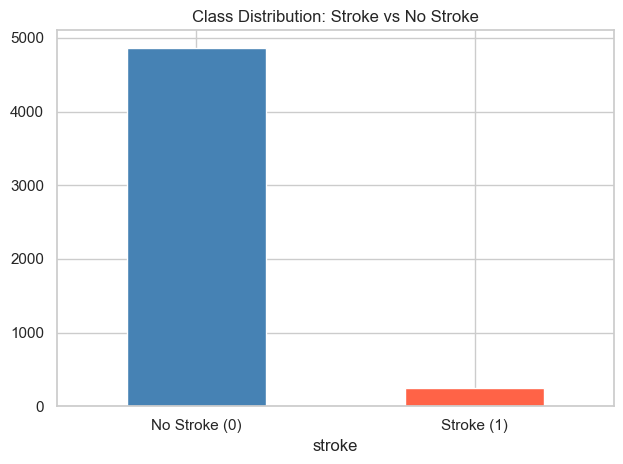

In [17]:
print(df['stroke'].value_counts())
print(f"\nPositive class rate: {df['stroke'].mean():.2%}")

fig, ax = plt.subplots()
df['stroke'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution: Stroke vs No Stroke')
ax.set_xticklabels(['No Stroke (0)', 'Stroke (1)'], rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'p1_class_distribution.png'), dpi=150)
plt.show()

## 3. Feature Distributions

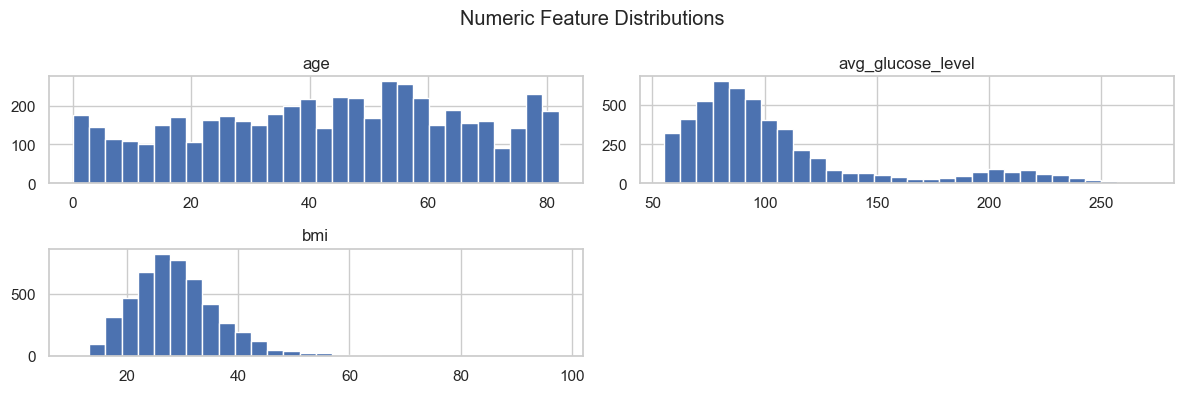

In [18]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
df[numeric_cols].hist(bins=30, figsize=(12, 4))
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'p1_numeric_distributions.png'), dpi=150)
plt.show()

In [19]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    print(df[col].value_counts(), '\n')

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64 

hypertension
0    4612
1     498
Name: count, dtype: int64 

heart_disease
0    4834
1     276
Name: count, dtype: int64 

ever_married
Yes    3353
No     1757
Name: count, dtype: int64 

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64 

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64 

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64 



## 4. Correlation Heatmap

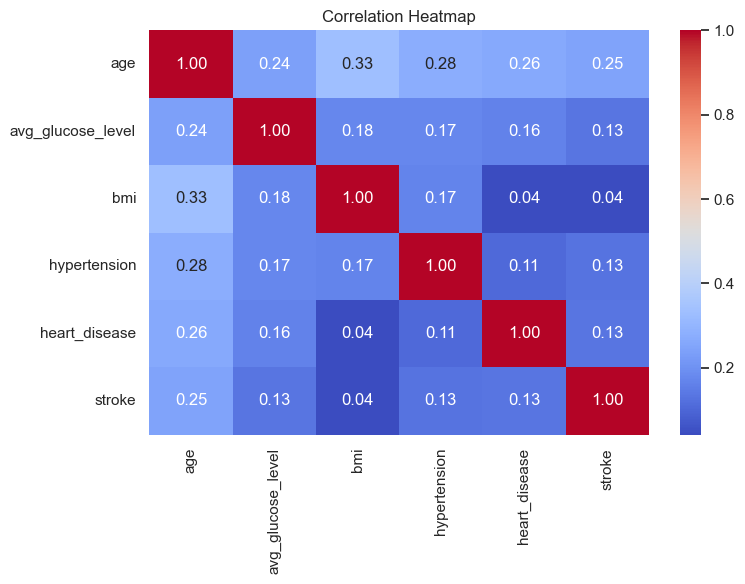

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[numeric_cols + ['hypertension', 'heart_disease', 'stroke']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'p1_correlation_heatmap.png'), dpi=150)
plt.show()

## 5. Data Cleaning

In [21]:
df_clean = df.copy()

# Drop id
df_clean.drop(columns=['id'], inplace=True)

# Handle gender = 'Other' (1 record) — drop or merge
print(f"Records with gender='Other': {(df_clean['gender'] == 'Other').sum()}")
df_clean = df_clean[df_clean['gender'].isin(['Male', 'Female'])].copy()

print(f"Shape after removing rare category: {df_clean.shape}")

# Impute BMI with median
bmi_median = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(bmi_median)
print(f'BMI missing after imputation: {df_clean["bmi"].isnull().sum()}')

# Smoking status 'Unknown' stays as its own category
print(df_clean['smoking_status'].value_counts())

# Final check
print("\nFinal missing values:")
print(df_clean.isnull().sum())

Records with gender='Other': 1
Shape after removing rare category: (5109, 11)
BMI missing after imputation: 0
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: count, dtype: int64

Final missing values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


## 6. Encoding & Scaling

In [22]:
df_encoded = pd.get_dummies(df_clean,
                             columns=['gender', 'ever_married', 'work_type',
                                      'Residence_type', 'smoking_status'],
                             drop_first=True)
print(f'Shape after encoding: {df_encoded.shape}')
df_encoded.head()

Shape after encoding: (5109, 16)


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


## 7. Save Processed Dataset

In [23]:
os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
df_encoded.to_csv(PROCESSED_PATH, index=False)
print(f'Saved to {PROCESSED_PATH}')

Saved to ..\..\data\processed\stroke_cleaned.csv
